# Assignment 1: Transfer Learning on OCT Images

## Import Libraries

In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import tensorflow as tf
from tensorflow.keras import applications
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Convolution2D, MaxPool2D, Dense, Flatten, Dropout
from tensorflow.keras.callbacks import TensorBoard, ModelCheckpoint, EarlyStopping
from tensorflow.keras.utils import plot_model

from pathlib import Path
from datetime import datetime

from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 2503706038242112074
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 83112099840
locality {
  bus_id: 1
  links {
  }
}
incarnation: 15896931622743085691
physical_device_desc: "device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:00:05.0, compute capability: 8.0"
xla_global_id: 416903419
]


## Dataset Paths and Hyperparameters

In [ ]:
# Dataset Path
data_dir = Path("/content/drive/My Drive/Spring 2026/ECGR 4116/Assignment1/Dataset")
train_dir = data_dir / "train"
test_dir = data_dir / "test"

# Image Size
img_width, img_height, img_depth = 128, 128, 3

# Hyperparameters
epochs = 25
batch_size = 28
lr = 0.0001
# freq = 20 (Not Used)

num_classes = 3 # DME, DRUSEN, NORMAL
train_valid_split = 0.2 # 80% and 20% split = training and validation

# 3-class classification
act_type = "softmax"
class_mode = "categorical"
loss_fun = "categorical_crossentropy"

print("Classes:", num_classes)
print("Type of classification: ", class_mode)
print("Loss function: ", loss_fun)
print("Activation function: ", act_type)

Classes: 3
Type of classification:  categorical
Loss function:  categorical_crossentropy
Activation function:  softmax


## Data Generators and Augmentation

In [ ]:
# Training - Augmentation and Validation Split
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    horizontal_flip = True,
    vertical_flip = True,
    rotation_range = 90,
    shear_range = 0.2,
    zoom_range = 0.2,
    fill_mode = "constant",
    validation_split = train_valid_split
)

# Training
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = (img_width, img_height),
    class_mode = class_mode,
    color_mode = "rgb",
    batch_size = batch_size,
    subset = "training",
    shuffle = True
)

# Validation
valid_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = (img_width, img_height),
    class_mode = class_mode,
    color_mode = "rgb",
    batch_size = batch_size,
    subset = "validation",
    shuffle = True
)

# Test generator
test_datagen = ImageDataGenerator(
    rescale = 1./255,
    # horizontal_flip = True,
    # vertical_flip = True,
    # rotation_range = 90,
    # shear_range = 0.2,
    # zoom_range = 0.15,
    # fill_mode = 'constant'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size = (img_width, img_height),
    class_mode = class_mode,
    color_mode = "rgb",
    batch_size = batch_size,
    shuffle = False
)

print("Class indices:", train_generator.class_indices)
print("Training samples:", train_generator.samples)
print("Validation samples:", valid_generator.samples)
print("Test samples:", test_generator.samples)

Found 1815 images belonging to 3 classes.
Found 453 images belonging to 3 classes.
Found 963 images belonging to 3 classes.
Class indices: {'DME': 0, 'DRUSEN': 1, 'NORMAL': 2}
Training samples: 1815
Validation samples: 453
Test samples: 963


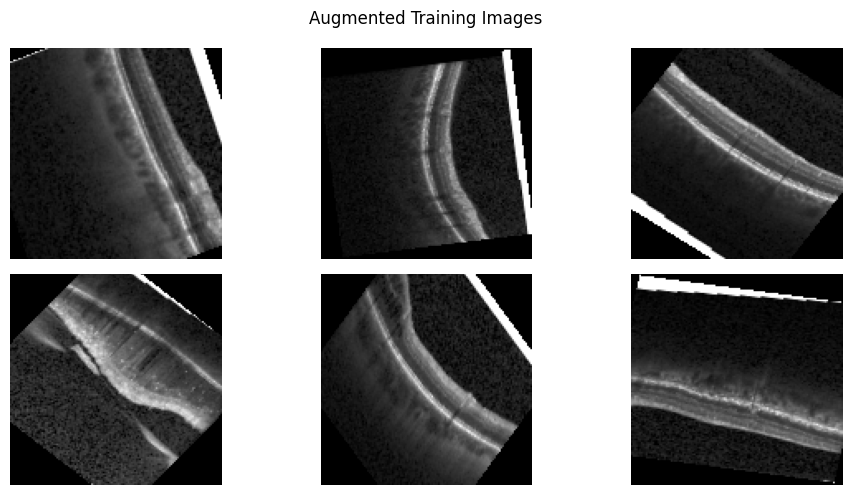

In [ ]:
# Preview
X_preview, y_preview = next(train_generator)

plt.figure(figsize = (10, 5))
for k in range(1, 7):
    sample_img = X_preview[k, :, :, :]
    plt.subplot(2, 3, k)
    plt.imshow(sample_img)
    plt.axis("off")
plt.suptitle("Augmented Training Images")
plt.tight_layout()
plt.show()

## Build Model
Used VGG16 with ImageNet weights as given in the example code provided.

In [ ]:
# Load VGG16 with ImageNet weights
base_model = applications.vgg16.VGG16(
    include_top = False,
    weights = "imagenet",
    input_shape = (img_width, img_height, img_depth)
)

for layer in base_model.layers[:-9]:
    layer.trainable = False

# Custom Model Layers
base_output = base_model.output
flat1 = Flatten()(base_output)
fc1 = Dense(8192, activation = "relu")(flat1)
dropfc1 = Dropout(0.5)(fc1)
fc2 = Dense(4096, activation = "relu")(dropfc1)
dropfc2 = Dropout(0.5)(fc2)
output = Dense(num_classes, activation = act_type)(dropfc2)

model = Model(inputs = base_model.input, outputs = output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8192)           │    67,117,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    33,558,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │        12,29

 Total params: 115,402,563 (440.23 MB)

 Trainable params: 113,667,075 (433.61 MB)

 Non-trainable params: 1,735,488 (6.62 MB)

## Compile Model

In [ ]:
# Compile the model
opt = Adam(learning_rate = lr)
model.compile(loss = loss_fun, optimizer = opt, metrics = ["accuracy"])

## Model Checkbacks

In [ ]:
# Early stopping
early_stop = EarlyStopping(monitor='val_loss', min_delta=0, patience=10, verbose=0, mode='auto', restore_best_weights=True)

# Model checkpoint
model_file = "best_model_vgg16.h5"
checkpoint = ModelCheckpoint(model_file, monitor = "val_loss", save_best_only = True, verbose = 1)

## Train Model

In [ ]:
history = model.fit(
    train_generator,
    epochs = epochs,
    validation_data = valid_generator,
    callbacks = [early_stop, checkpoint]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.3732 - loss: 1.3715
Epoch 1: val_loss improved from inf to 1.03898, saving model to best_model_vgg16.h5


65/65 ━━━━━━━━━━━━━━━━━━━━ 47s 578ms/step - accuracy: 0.3737 - loss: 1.3684 - val_accuracy: 0.4283 - val_loss: 1.0390
Epoch 2/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.4493 - loss: 1.0227
Epoch 2: val_loss improved from 1.03898 to 0.88541, saving model to best_model_vgg16.h5


65/65 ━━━━━━━━━━━━━━━━━━━━ 21s 309ms/step - accuracy: 0.4494 - loss: 1.0227 - val_accuracy: 0.6534 - val_loss: 0.8854
Epoch 3/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.5023 - loss: 0.9979
Epoch 3: val_loss improved from 0.88541 to 0.79103, saving model to best_model_vgg16.h5


65/65 ━━━━━━━━━━━━━━━━━━━━ 23s 358ms/step - accuracy: 0.5021 - loss: 0.9977 - val_accuracy: 0.6225 - val_loss: 0.7910
Epoch 4/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.5355 - loss: 0.9179
Epoch 4: val_loss did not improve from 0.79103
65/65 ━━━━━━━━━━━━━━━━━━━━ 20s 256ms/step - accuracy: 0.5354 - loss: 0.9181 - val_accuracy: 0.5872 - val_loss: 0.8225
Epoch 5/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.5771 - loss: 0.8730
Epoch 5: val_loss improved from 0.79103 to 0.61210, saving model to best_model_vgg16.h5


...

65/65 ━━━━━━━━━━━━━━━━━━━━ 23s 358ms/step - accuracy: 0.8324 - loss: 0.4074 - val_accuracy: 0.8190 - val_loss: 0.3594
Epoch 17/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.8653 - loss: 0.3501
Epoch 17: val_loss improved from 0.35944 to 0.33135, saving model to best_model_vgg16.h5


65/65 ━━━━━━━━━━━━━━━━━━━━ 24s 365ms/step - accuracy: 0.8652 - loss: 0.3504 - val_accuracy: 0.8455 - val_loss: 0.3313
Epoch 18/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.8647 - loss: 0.3567
Epoch 18: val_loss did not improve from 0.33135
65/65 ━━━━━━━━━━━━━━━━━━━━ 20s 259ms/step - accuracy: 0.8644 - loss: 0.3574 - val_accuracy: 0.7815 - val_loss: 0.4313
Epoch 19/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.9056 - loss: 0.2679
Epoch 19: val_loss did not improve from 0.33135
65/65 ━━━━━━━━━━━━━━━━━━━━ 17s 257ms/step - accuracy: 0.9054 - loss: 0.2681 - val_accuracy: 0.8433 - val_loss: 0.3597
Epoch 20/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.9235 - loss: 0.2147
Epoch 20: val_loss did not improve from 0.33135
65/65 ━━━━━━━━━━━━━━━━━━━━ 17s 256ms/step - accuracy: 0.9232 - loss: 0.2154 - val_accuracy: 0.7925 - val_loss: 0.5214
Epoch 21/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.8712 - loss: 0.3865
Epoch 21: val_loss improved from 0.3

65/65 ━━━━━━━━━━━━━━━━━━━━ 20s 304ms/step - accuracy: 0.8710 - loss: 0.3867 - val_accuracy: 0.8985 - val_loss: 0.2788
Epoch 22/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.9188 - loss: 0.2197
Epoch 22: val_loss improved from 0.27876 to 0.23847, saving model to best_model_vgg16.h5


65/65 ━━━━━━━━━━━━━━━━━━━━ 23s 362ms/step - accuracy: 0.9190 - loss: 0.2193 - val_accuracy: 0.9272 - val_loss: 0.2385
Epoch 23/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.9436 - loss: 0.1556
Epoch 23: val_loss improved from 0.23847 to 0.20583, saving model to best_model_vgg16.h5


65/65 ━━━━━━━━━━━━━━━━━━━━ 23s 308ms/step - accuracy: 0.9436 - loss: 0.1557 - val_accuracy: 0.9249 - val_loss: 0.2058
Epoch 24/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.9259 - loss: 0.1898
Epoch 24: val_loss did not improve from 0.20583
65/65 ━━━━━━━━━━━━━━━━━━━━ 20s 313ms/step - accuracy: 0.9262 - loss: 0.1893 - val_accuracy: 0.8565 - val_loss: 0.4322
Epoch 25/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.9330 - loss: 0.1971
Epoch 25: val_loss did not improve from 0.20583
65/65 ━━━━━━━━━━━━━━━━━━━━ 17s 255ms/step - accuracy: 0.9331 - loss: 0.1968 - val_accuracy: 0.9338 - val_loss: 0.2167


## Plot Training and Validation Loss

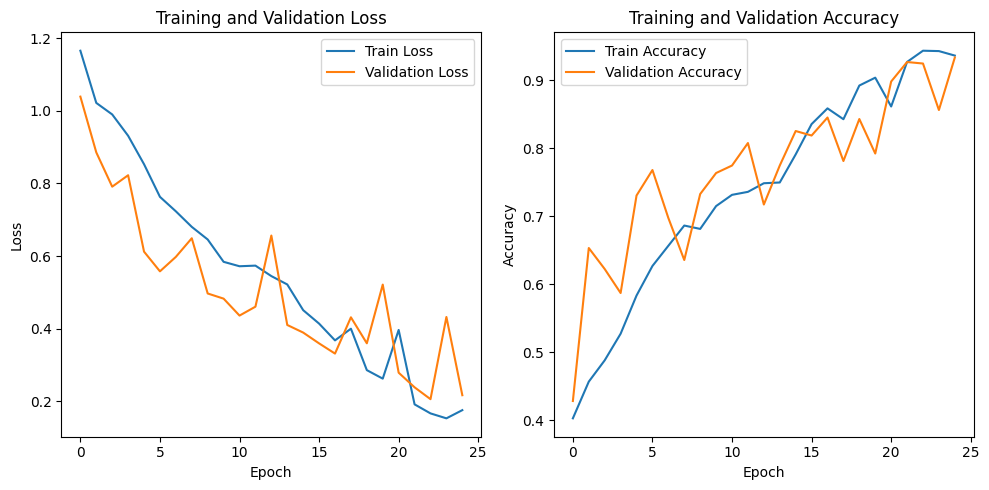

In [ ]:
plt.figure(figsize = (10, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label = "Train Loss")
plt.plot(history.history["val_loss"], label = "Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label = "Train Accuracy")
plt.plot(history.history["val_accuracy"], label = "Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.savefig("training_curves.png")
plt.show()

## Test and Confusion Matrix

In [ ]:
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis = 1)
y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())
print("Test classes:", class_names)
print("Test accuracy: {:.2f}%".format(100 * np.sum(y_pred == y_true) / len(y_true)))

35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 231ms/step
Test classes: ['DME', 'DRUSEN', 'NORMAL']
Test accuracy: 87.54%


In [ ]:
def plot_confusion_matrix(y_true, y_pred, classes,
                          normalize=False,
                          title=None,
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if not title:
        if normalize:
            title = "Normalized confusion matrix"
        else:
            title = "Confusion matrix, without normalization"

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    # Only use the labels that appear in the data
    classes = classes#[unique_labels(y_true, y_pred)]
    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print("Confusion matrix, without normalization")

    print(cm)

    fig, ax = plt.subplots()
    im = ax.imshow(cm, interpolation="nearest", cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    # We want to show all ticks...
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           # ... and label them with the respective list entries
           xticklabels=classes, yticklabels=classes,
           title=title,
           ylabel="True label",
           xlabel="Predicted label")

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")

    # Loop over data dimensions and create text annotations.
    fmt = ".2f" if normalize else "d"
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    fig.tight_layout()
    return ax

Normalized confusion matrix
[[0.99344262 0.00655738 0.        ]
 [0.02714932 0.97285068 0.        ]
 [0.25400458 0.00228833 0.74370709]]


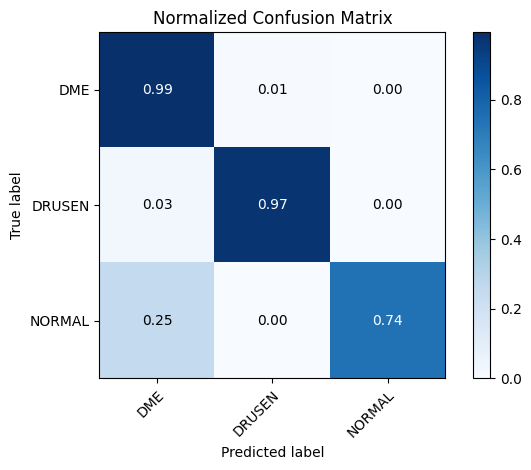

In [ ]:
plot_confusion_matrix(
    y_true,
    y_pred,
    classes = class_names,
    normalize = True,
    title = "Normalized Confusion Matrix"
)
plt.savefig("confusion_matrix.png")
plt.show()